# Stage 1 RAE Training
Frozen DINOv3-L encoder → Adapter → ViT Decoder  
Three-phase schedule: L1+LPIPS → +Disc → +GAN

## Setup
Run all cells in order. Restart kernel if you change encoder.py or other source files.

In [1]:
import os, sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.chdir("c:/Users/naqee/OneDrive/Desktop/CSC415 Project/RAEDiTRobotics")
sys.path.insert(0, os.getcwd())

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s %(message)s")

import torch
import numpy as np
import matplotlib
%matplotlib inline

import matplotlib.pyplot as plt

from data_pipeline.datasets.stage1_dataset import Stage1Dataset
from models.encoder import FrozenMultiViewEncoder
from models.adapter import TrainableAdapter
from models.decoder import ViTDecoder
from models.losses import create_lpips_net
from training.train_stage1 import Stage1Config, train_stage1

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Device: cpu


## Configuration
Edit `HDF5_PATH` and hyperparameters below. Test with `num_epochs=1` on CPU to verify (training might take a while), then scale up on GPU.

In [3]:
# ── Edit these ──────────────────────────────────────────
HDF5_PATH = "C:/Users/naqee/OneDrive/Desktop/CSC415 Project/data/unified/robomimic/lift/ph.hdf5"

# config = Stage1Config(
#     hdf5_path=HDF5_PATH,
#     batch_size=16,            # lower if OOM
#     num_workers=4,            # 0 for debugging

#     # Training schedule
#     num_epochs=50,
#     epoch_start_disc=6,       # Phase 2: start disc training
#     epoch_start_gan=8,        # Phase 3: add GAN loss

#     # Loss weights (Zheng et al. Table 12)
#     omega_L=1.0,              # LPIPS weight
#     omega_G=0.75,             # GAN weight (before adaptive lambda)

#     # Optimizer
#     lr_gen=1e-4,
#     lr_disc=1e-4,
#     betas=(0.5, 0.9),
#     weight_decay=0.01,

#     # Checkpointing
#     save_every=5,
#     save_dir="checkpoints/stage1",

#     # Model
#     disc_pretrained=True,     # real DINO-S/8 for discriminator
# )

config = Stage1Config(
    hdf5_path=HDF5_PATH,
    batch_size=4,
    num_workers=0,
    num_epochs=1,         # just 1 epoch to verify
    epoch_start_disc=0,   # test all phases in 1 epoch
    epoch_start_gan=0,
    save_every=1,
    save_dir="checkpoints/stage1",
    disc_pretrained=True,
)


print(config)

Stage1Config(hdf5_path='C:/Users/naqee/OneDrive/Desktop/CSC415 Project/data/unified/robomimic/lift/ph.hdf5', batch_size=4, num_workers=0, num_epochs=1, epoch_start_disc=0, epoch_start_gan=0, omega_L=1.0, omega_G=0.75, lr_gen=0.0001, lr_disc=0.0001, betas=(0.5, 0.9), weight_decay=0.01, save_every=1, save_dir='checkpoints/stage1', disc_pretrained=True)


In [4]:
train_ds = Stage1Dataset(config.hdf5_path, split="train")
valid_ds = Stage1Dataset(config.hdf5_path, split="valid")
print(f"Train samples: {len(train_ds)}")
print(f"Valid samples: {len(valid_ds)}")

sample = train_ds[0]
for k, v in sample.items():
    print(f"  {k}: {v.shape} {v.dtype}")

Train samples: 8640
Valid samples: 1026
  images_enc: torch.Size([4, 3, 224, 224]) torch.float32
  images_target: torch.Size([4, 3, 224, 224]) torch.float32
  view_present: torch.Size([4]) torch.bool


Views 0 and 3 are real cameras (robomimic); views 1 and 2 are zero-padded placeholders.

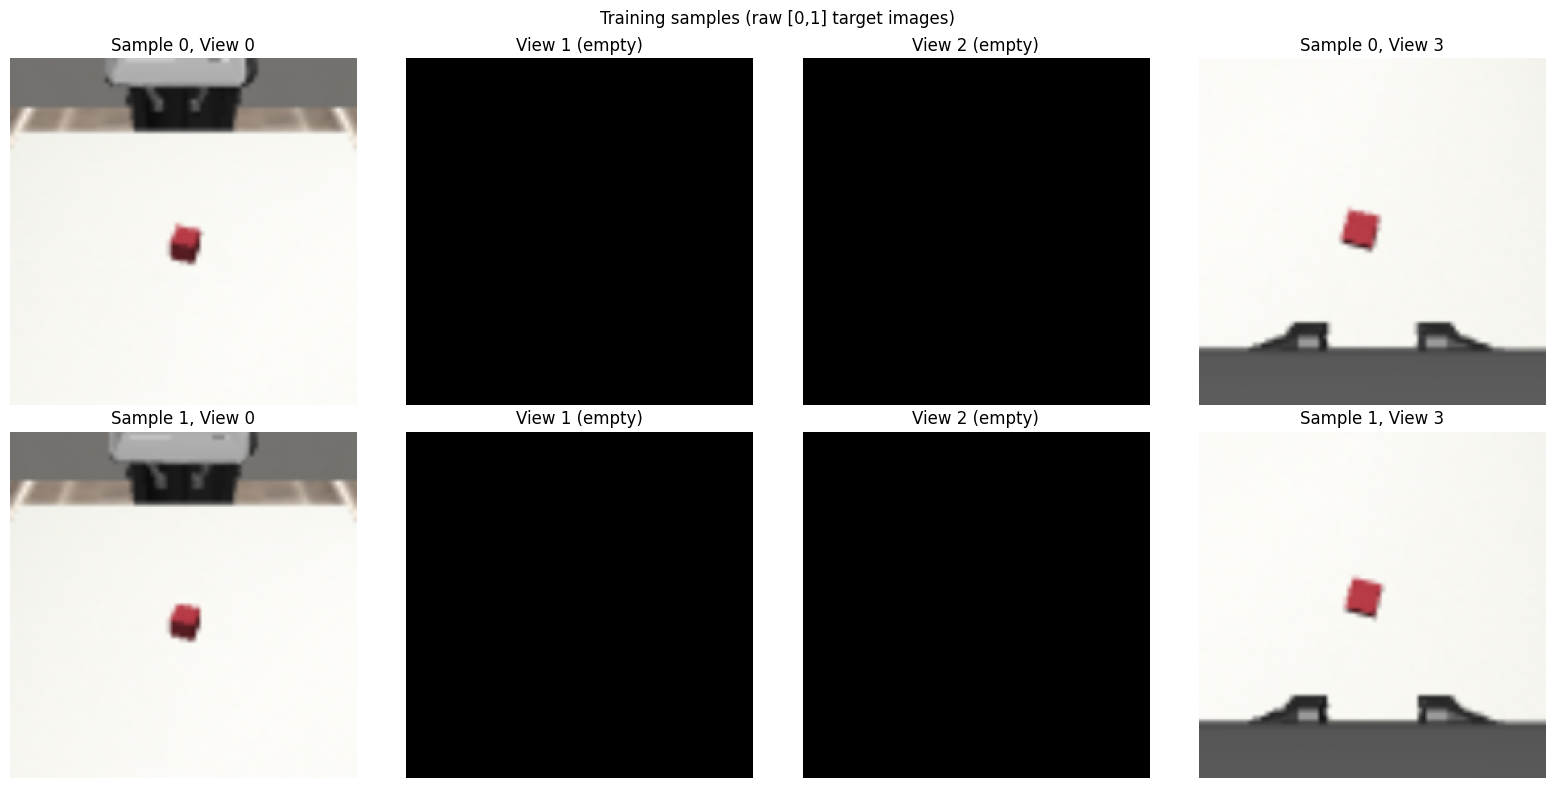

Saved training_samples.png


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Training samples (raw [0,1] target images)")

for i in range(min(2, len(train_ds))):
    sample = train_ds[i]
    imgs = sample["images_target"]    # (K, 3, H, W)
    vp = sample["view_present"]       # (K,)
    for k in range(4):
        ax = axes[i, k]
        if vp[k]:
            img = imgs[k].permute(1, 2, 0).numpy()  # (H, W, 3)
            ax.imshow(img)
            ax.set_title(f"Sample {i}, View {k}")
        else:
            ax.set_title(f"View {k} (empty)")
            ax.imshow(np.zeros((224, 224, 3)))
        ax.axis("off")

plt.tight_layout()
plt.savefig("training_samples.png", dpi=100)
plt.show()
print("Saved training_samples.png")

## Model Setup

In [6]:
encoder = FrozenMultiViewEncoder(pretrained=True).to(device)

n_params = sum(p.numel() for p in encoder.parameters())
n_frozen = sum(p.numel() for p in encoder.parameters() if not p.requires_grad)
print(f"Encoder: {n_params/1e6:.1f}M params (all frozen: {n_frozen == n_params})")

2026-03-08 15:18:12,200 httpx HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
2026-03-08 15:18:12,250 httpx HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitl16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Encoder: 303.1M params (all frozen: True)


In [7]:
adapter = TrainableAdapter().to(device)
decoder = ViTDecoder().to(device)

n_adapter = sum(p.numel() for p in adapter.parameters() if p.requires_grad)
n_decoder = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Adapter: {n_adapter/1e6:.2f}M trainable params")
print(f"Decoder: {n_decoder/1e6:.2f}M trainable params")
print(f"Total trainable: {(n_adapter + n_decoder)/1e6:.2f}M")
print(f"Decoder last_layer_weight: {decoder.last_layer_weight.shape}")

Adapter: 1.57M trainable params
Decoder: 25.71M trainable params
Total trainable: 27.29M
Decoder last_layer_weight: torch.Size([768, 512])


c:\Users\naqee\OneDrive\Desktop\CSC415 Project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


### Sanity Check
One forward pass through the full pipeline. Verifies shapes connect and output is in [0, 1].

In [8]:
# One forward pass through the entire pipeline
sample = train_ds[0]
imgs_enc = sample["images_enc"].unsqueeze(0).to(device)     # (1, K, 3, 224, 224)
vp = sample["view_present"].unsqueeze(0)                     # (1, K)

B, K = vp.shape
mask = vp.reshape(-1)
x = imgs_enc.reshape(B * K, 3, 224, 224)[mask]               # (N, 3, 224, 224)

with torch.no_grad():
    tokens = encoder(x)
print(f"1. Encoder output:  {tokens.shape}")                  # (N, 196, 1024)

adapted = adapter(tokens)
print(f"2. Adapter output:  {adapted.shape}")                 # (N, 196, 512)

noisy = adapter.noise_augment(adapted)
print(f"3. After noise:     {noisy.shape}")                   # (N, 196, 512)

pred = decoder(noisy)
print(f"4. Decoder output:  {pred.shape}")                    # (N, 3, 224, 224)
print(f"   Output range:    [{pred.min():.3f}, {pred.max():.3f}]")
print("\nSanity check passed!")

1. Encoder output:  torch.Size([2, 196, 1024])
2. Adapter output:  torch.Size([2, 196, 512])
3. After noise:     torch.Size([2, 196, 512])
4. Decoder output:  torch.Size([2, 3, 224, 224])
   Output range:    [0.004, 0.997]

Sanity check passed!


## Training
Three phases: (1) L1+LPIPS only → (2) +discriminator → (3) +GAN with adaptive lambda.  
CPU: ~30-60 min/epoch. GPU recommended for full runs.

In [9]:
train_stage1(
    config,
    encoder=encoder,
    adapter=adapter,
    decoder=decoder,
    device=device,
)

Using cache found in C:\Users\naqee/.cache\torch\hub\facebookresearch_dino_main


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\naqee\OneDrive\Desktop\CSC415 Project\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\naqee\OneDrive\Desktop\CSC415 Project\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
2026-03-08 15:18:20,049 training.train_stage1 Stage 1 training: epochs 0-0, 8640 train / 1026 valid samples
2026-03-08 15:18:20,049 training.train_stage1 Phase schedule: disc @ epoch 0, GAN @ epoch 0


Loading model from: c:\Users\naqee\OneDrive\Desktop\CSC415 Project\.venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth


Epoch 0 [phase3_gan]:   0%|          | 0/2160 [00:00<?, ?it/s]c:\Users\naqee\OneDrive\Desktop\CSC415 Project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 0 [phase3_gan]:   1%|          | 18/2160 [04:20<8:37:08, 14.49s/it]


KeyboardInterrupt: 

In [ ]:
# Uncomment to resume from checkpoint:
# train_stage1(
#     config,
#     encoder=encoder,
#     adapter=adapter,
#     decoder=decoder,
#     device=device,
#     resume_from="checkpoints/stage1/best.pt",
# )

## Evaluation
Load best checkpoint and compare original vs reconstructed images.

In [ ]:
from training.train_stage1 import load_checkpoint
from models.discriminator import PatchDiscriminator

# Reload fresh models
adapter_eval = TrainableAdapter().to(device)
decoder_eval = ViTDecoder().to(device)
disc_eval = PatchDiscriminator(pretrained=config.disc_pretrained).to(device)

opt_gen_dummy = torch.optim.AdamW(
    list(adapter_eval.parameters()) + list(decoder_eval.parameters()), lr=1e-4
)
opt_disc_dummy = torch.optim.AdamW(disc_eval.head.parameters(), lr=1e-4)

ckpt_path = "checkpoints/stage1/best.pt"
epoch = load_checkpoint(ckpt_path, adapter_eval, decoder_eval, disc_eval, opt_gen_dummy, opt_disc_dummy)
print(f"Loaded checkpoint from epoch {epoch - 1}")

adapter_eval.eval()
decoder_eval.eval()

# Reconstruct a few samples
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
fig.suptitle("Original (left) vs Reconstructed (right)")

for i in range(3):
    sample = valid_ds[i * 10]
    imgs_enc = sample["images_enc"].unsqueeze(0).to(device)
    imgs_tgt = sample["images_target"]
    vp = sample["view_present"].unsqueeze(0)

    mask = vp.reshape(-1)
    x = imgs_enc.reshape(-1, 3, 224, 224)[mask]

    with torch.no_grad():
        tokens = encoder(x)
        adapted = adapter_eval(tokens)
        pred = decoder_eval(adapted)

    # Show first valid view
    orig = imgs_tgt[0].permute(1, 2, 0).numpy()
    recon = pred[0].cpu().permute(1, 2, 0).numpy()

    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"Original (sample {i})")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(recon)
    axes[i, 1].set_title(f"Reconstructed")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("reconstructions.png", dpi=100)
plt.show()
print("Saved reconstructions.png")

In [ ]:
from models.losses import l1_loss, lpips_loss_fn
from torch.utils.data import DataLoader

lpips_net = create_lpips_net().to(device)
val_loader = DataLoader(valid_ds, batch_size=config.batch_size, num_workers=0)

total_l1, total_lpips, n = 0.0, 0.0, 0

adapter_eval.eval()
decoder_eval.eval()

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        B, K = batch["view_present"].shape
        mask = batch["view_present"].reshape(-1)
        x = batch["images_enc"].reshape(B * K, 3, 224, 224)[mask]
        tgt = batch["images_target"].reshape(B * K, 3, 224, 224)[mask]

        tokens = encoder(x)
        pred = decoder_eval(adapter_eval(tokens))

        total_l1 += l1_loss(pred, tgt).item()
        total_lpips += lpips_loss_fn(pred, tgt, lpips_net).item()
        n += 1

print(f"Val L1:    {total_l1 / n:.4f}")
print(f"Val LPIPS: {total_lpips / n:.4f}")
print(f"Val Rec:   {(total_l1 + total_lpips) / n:.4f}")